# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Kalpana

**Dataset:** https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.** 

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [1]:
# Core libraries
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
# pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Disable scientific notation on all axes globally
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-99, 99)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

I am trying to predict Concrete compressive strenth which measure how much pressure a concrete sample can withstand before breaking. 


### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**
A predictive model lets civil engineering team estimate strength immediately from the mix design, without waiting.

This reduces costs, improves safety margins, and speeds up construction planning by allowing simulation of different mix ratios before physically testing them.


### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

These concrete features like cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and curing age (in days) will help predict the target.



## Section 2: Dataset Overview

### 2.1 Load Your Data

In [2]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/concrete_data.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 1,030 rows, 9 columns

Column names:
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age', 'concrete_compressive_strength']


In [3]:
# TODO: View the first 5 rows of your dataframe
#
# Hint: Use .head()

# YOUR CODE HERE:
df.head(5)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
# TODO: View the last 5 rows of your dataframe
#
# Hint: Use .tail()

# YOUR CODE HERE:
df.tail(5)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


### 2.2 Data Types and Info

In [5]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
# Hint: Use .info()

# YOUR CODE HERE:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
# TODO: Get summary statistics for numerical columns
#
# Hint: Use .describe()

# YOUR CODE HERE:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
# TODO: Get summary statistics for categorical columns
#
# Hint: Use .describe(include='object')

# YOUR CODE HERE
if df.select_dtypes(include='object').shape[1] > 0:
    df.describe(include='object')
else:
    print("No categorical columns found in the dataset.")

No categorical columns found in the dataset.


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
1. Where did this data come from? (Kaggle link, source)
2. What does each row represent?
3. How many features do you have?
4. What types of features do you have? (numerical, categorical)

**Your description:**
1. The dataset comes from Kaggle and source link is https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set

2. Each row represents one concrete sample with its mix design 
   (ingredient amounts + curing age) and the resulting compressive strength. All are numerical features

3. There are 8 input features + 1 target = 9 columns total.

4. All numerical; no categorical features.


## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [8]:
# Define your target variable
TARGET = 'concrete_compressive_strength'  # <-- set target variable

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: concrete_compressive_strength

Basic Statistics:
count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: concrete_compressive_strength, dtype: float64


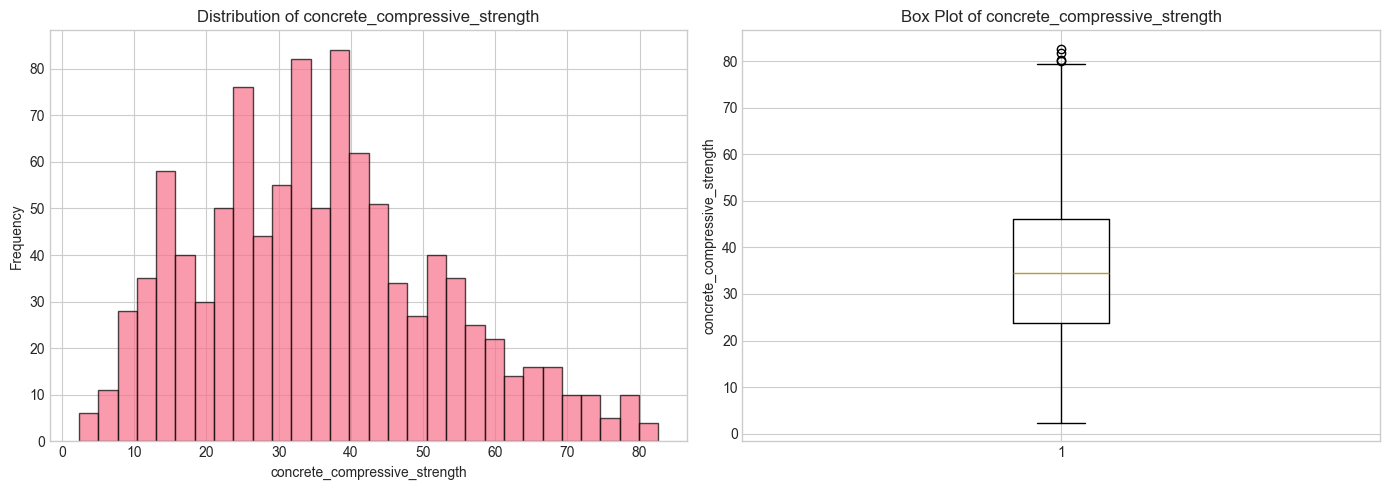


Skewness: 0.42
→ Target is approximately symmetric.


In [9]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [10]:

# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Duplicate rows: {duplicate_count:,} ({duplicate_percentage:.2f}%)")

Duplicate rows: 25 (2.43%)


In [11]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)
missing_df

,Missing Count,Missing %


In [12]:
# Visualize missing values (if any)
if missing_count.sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

✓ No missing values in the dataset!


### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**

1. Is your target variable normally distributed or skewed?

2. Are there any obvious outliers in the target?

3. How much missing data do you have to deal with?
  
4. Are there any duplicate rows?

5. Any surprises or interesting findings?



**Your observations:**

[Write your observations here]

1. Yes, target variable is approximately symmetric (i-e: normally distributed).

2. Yes i see that these oiutliers 
   water: 15 outliers (1.5%) | bounds: [127.15, 232.35]
   superplasticizer: 10 outliers (1.0%) | bounds: [-15.00, 25.00]
   fine_aggregate : 5 outliers (0.5%) | bounds: [577.45, 969.05]
   age: 59 outliers (5.9%) | bounds: [-66.50, 129.50]
   concrete_compressive_strength: 8 outliers (0.8%) | bounds: [-8.50, 76.89]

3. No missing data.
   
4. There are 25 duplicate rows.

5. The main surprise is that concrete strength is a highly non-linear problem — no single raw ingredient explains it well. We need cement, water,
curing age, superplasticizer combine together to get good result of target prediction.

---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [13]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

# YOUR CODE HERE:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

Numerical features (8): ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age']


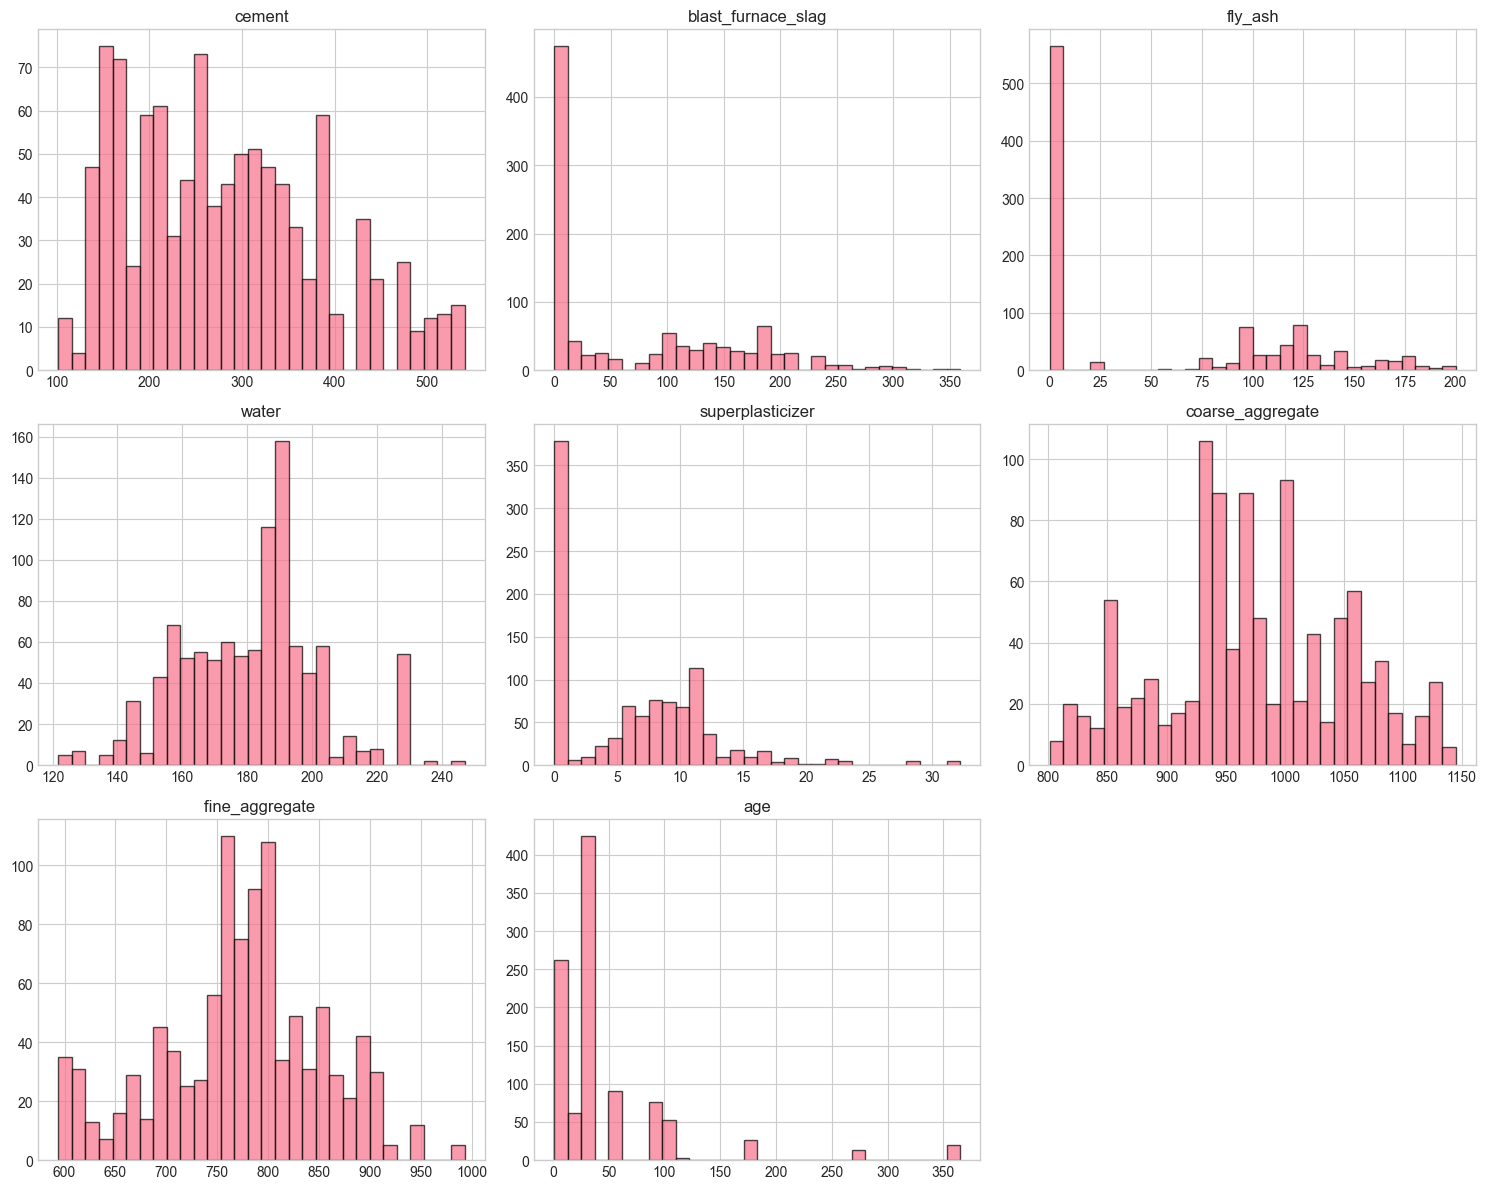

In [14]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [15]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

# YOUR CODE HERE:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) == 0:
    print("No categorical columns found in the dataset.")
else:
    print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

    for col in categorical_cols:
        print(f"\nColumn Name: {col}")
        print(f"Number of unique values: {df[col].nunique()}")
        print(f"Top 10 value counts: {df[col].value_counts().head(10)}")

No categorical columns found in the dataset.


In [16]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

No categorical columns with ≤10 unique values to plot.


### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

In [17]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

No suitable categorical columns for this analysis.


### 4.4 Correlation Analysis

List of columns: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age', 'concrete_compressive_strength']


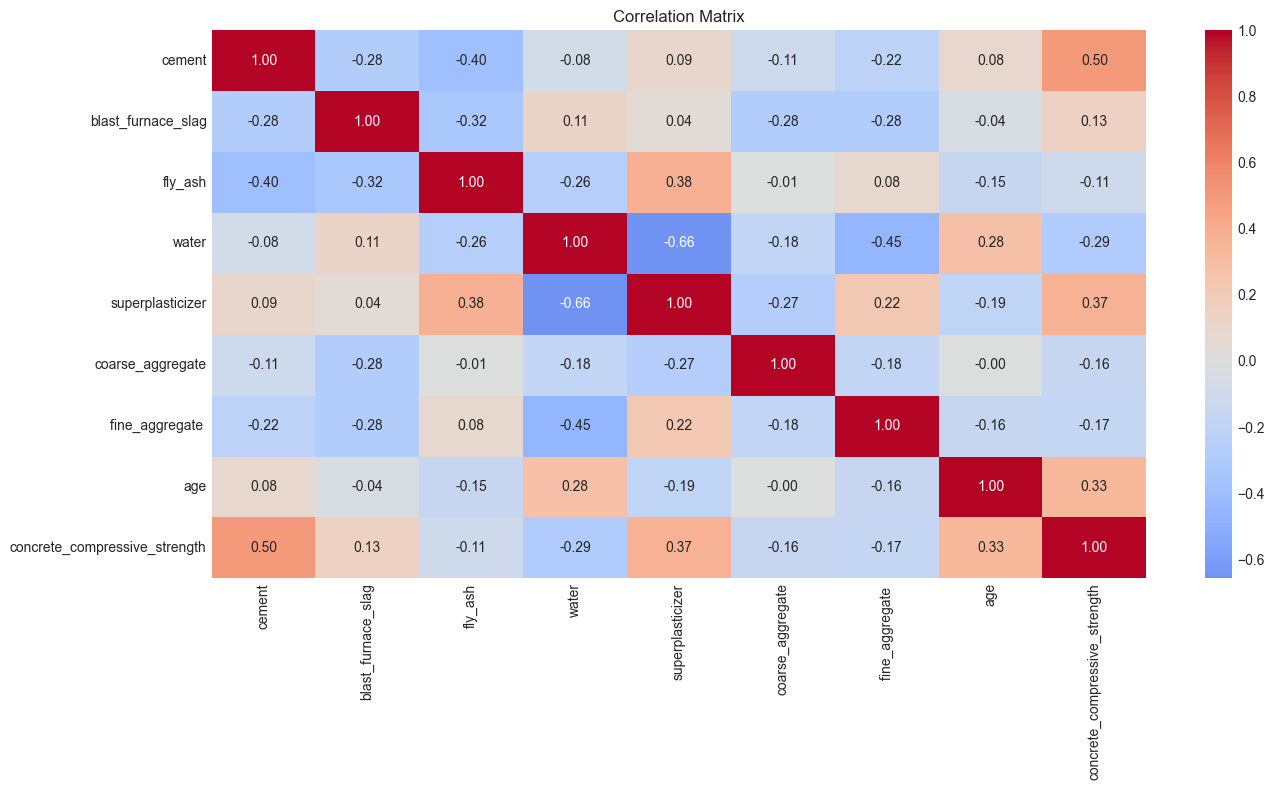

In [18]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:
columns = numerical_cols + [TARGET]
print(f"List of columns: {columns}")

correlation_matrix = df[columns].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [19]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:
target_correlations = correlation_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlations with TARGET:")
print(target_correlations)

strong_correlations = target_correlations[abs(target_correlations) > 0.5]
if len(strong_correlations) > 0:
    print(f"\nStrong correlations (|r| > 0.5): {len(strong_correlations)}")
    print(strong_correlations)
else:
    print(f"No features have a strong correlation (|r| > 0.5) with '{TARGET}'.")
    print("(Refer to the sorted list above to see the closest correlations.)")

Correlations with TARGET:
cement                0.497832
superplasticizer      0.366079
age                   0.328873
blast_furnace_slag    0.134829
fly_ash              -0.105755
coarse_aggregate     -0.164935
fine_aggregate       -0.167241
water                -0.289633
Name: concrete_compressive_strength, dtype: float64
No features have a strong correlation (|r| > 0.5) with 'concrete_compressive_strength'.
(Refer to the sorted list above to see the closest correlations.)


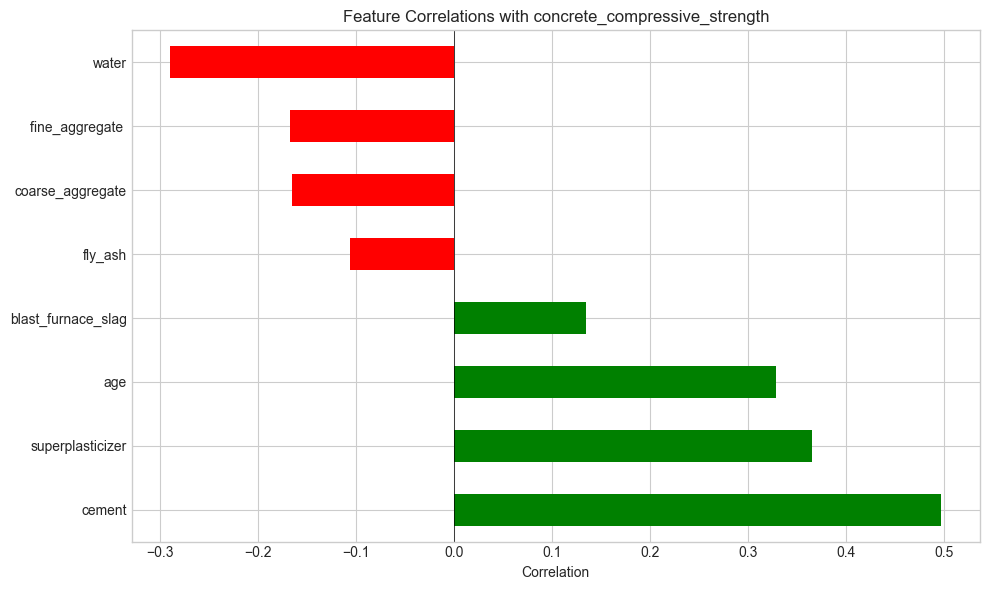

In [20]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

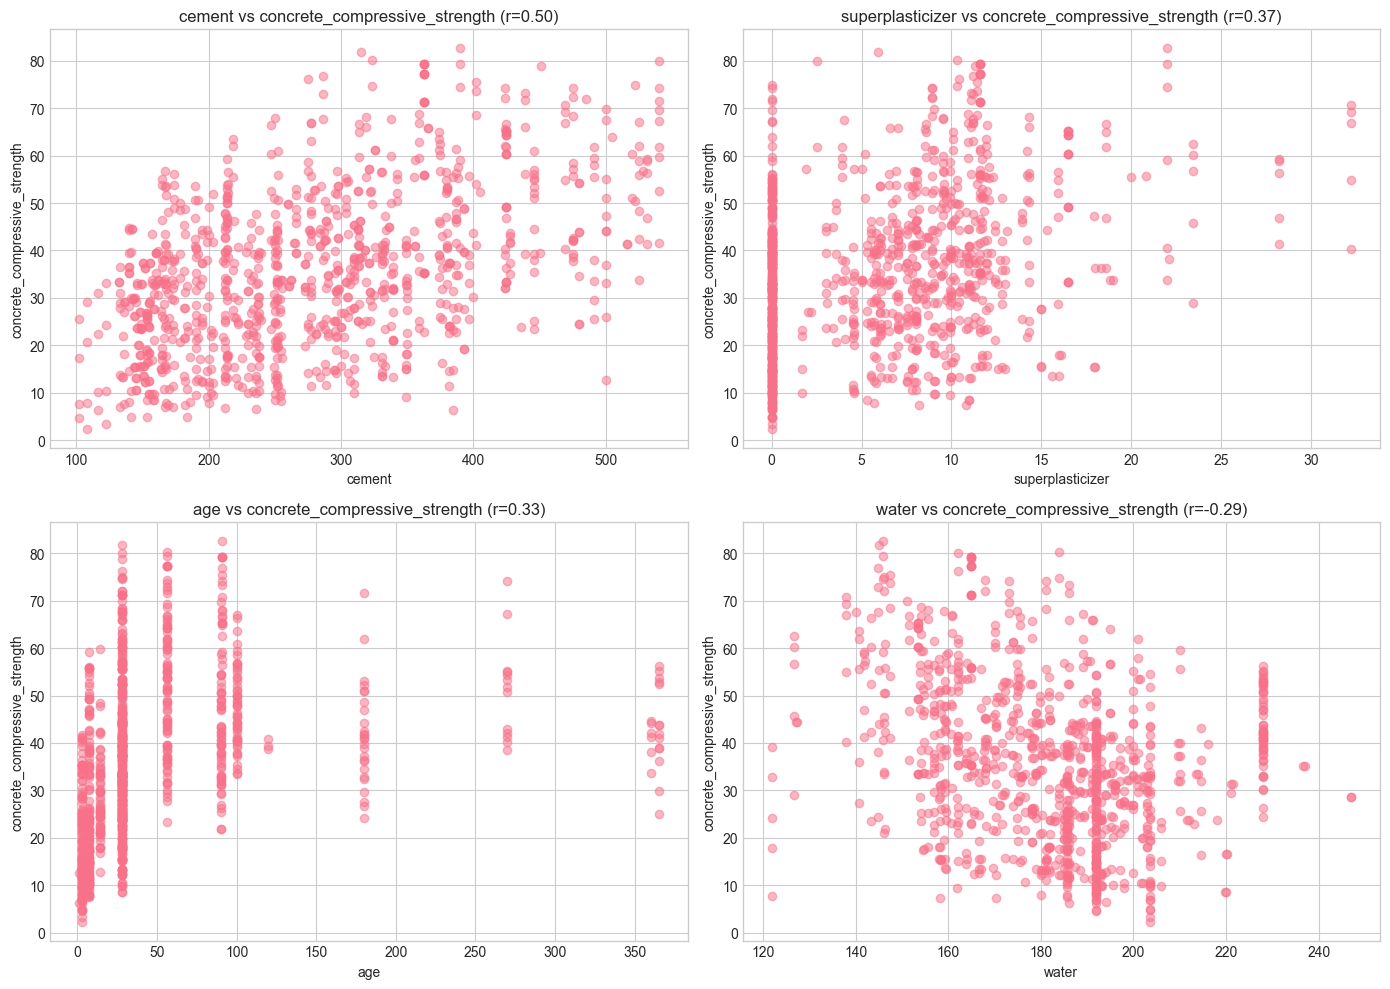

In [21]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

In [22]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!
# For example, you could:
# - Explore interactions between features
# - Create new features based on domain knowledge
# - Analyze outliers in more detail  
# Look at feature interactions with strong correlations to the target
# YOUR CODE HERE:

# 


In [23]:
# More exploration...

**What additional insights did you discover?**

[Describe any additional findings from your custom exploration


### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**

[Write your summary here]

1. These features (cement, superplasticizer, age, blast_furnace_slag) are most correlated to the target. 

2. No categorical features.  

3. No, all features are important.

4. I see that no strong predictors exist. There are zero missing data cell values. It can be non linear model dataset.

5. Yes, the below outliers are the concerns about the data:-

   - water: 15 outliers (1.5%) | bounds: [127.15, 232.35]
   - superplasticizer: 10 outliers (1.0%) | bounds: [-15.00, 25.00]
   - fine_aggregate : 5 outliers (0.5%) | bounds: [577.45, 969.05]
   - age: 59 outliers (5.9%) | bounds: [-66.50, 129.50]
   - concrete_compressive_strength: 8 outliers (0.8%) | bounds: [-8.50, 76.89]

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [24]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

# YOUR CODE HERE:
df_clean = df.copy()

print(f"Starting shape: {df_clean.shape}")

Starting shape: (1030, 9)


In [25]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: []

3. High cardinality (>100 unique): []

4. Low variance (>95% same value): []


In [26]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
    # Add column names to drop here, e.g.:
    # 'id',
    # 'url',
    *high_missing,  # Drop columns with >50% missing values
    *potential_ids,  # Drop potential ID/URL columns
    *high_cardinality,  # Drop high cardinality categorical columns
    *low_variance  # Drop low variance columns identified earlier
]
columns_to_drop = list(set(columns_to_drop))  # Remove duplicates if any

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

No columns dropped. Update the list above if needed.


**Explain which columns you dropped and why:**

I didnt drop any columns as there are no columns with missing values >50%, no id columns, no categorical columns and no low variance columns. 

### 5.2 Handle Duplicate Rows

In [27]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

# YOUR CODE HERE:
before_count = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_count = len(df_clean)
duplicates_removed = before_count - after_count

print(f"Duplicate rows removed: {duplicates_removed:,}")
print(f"New shape after removing duplicates: {df_clean.shape}")

Duplicate rows removed: 25
New shape after removing duplicates: (1005, 9)


### 5.3 Handle Missing Values

In [28]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
Series([], dtype: int64)


In [29]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

# YOUR CODE HERE:

df_clean.info()

# Impute numerical columns with median
for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical columns with mode
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


#Drop rows if missing target variable
df_clean[TARGET] = df_clean[TARGET].replace(0, np.nan)
missing_target = df_clean[TARGET].isnull().sum()
print(f"\nMissing values in target after replacing zeros: {missing_target}")

if missing_target > 0:
    print(f"Dropping {missing_target} rows with missing target variable...")
    df_clean = df_clean.dropna(subset=[TARGET])
else:
    print("No missing values in target variable after handling.\n")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1005 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1005 non-null   float64
 1   blast_furnace_slag             1005 non-null   float64
 2   fly_ash                        1005 non-null   float64
 3   water                          1005 non-null   float64
 4   superplasticizer               1005 non-null   float64
 5   coarse_aggregate               1005 non-null   float64
 6   fine_aggregate                 1005 non-null   float64
 7   age                            1005 non-null   int64  
 8   concrete_compressive_strength  1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 78.5 KB

Missing values in target after replacing zeros: 0
No missing values in target variable after handling.

<class 'pandas.core.frame.DataFrame'>
Index: 1005 entries, 0 to 1029
Data columns (

In [30]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

[Describe what you did for each column and why]

These dataset has no missing value data cells.

### 5.4 Handle Outliers (if needed)

In [31]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
blast_furnace_slag: 2 outliers (0.2%) | bounds: [-213.75, 356.25]
water: 15 outliers (1.5%) | bounds: [127.15, 232.35]
superplasticizer: 10 outliers (1.0%) | bounds: [-15.00, 25.00]
fine_aggregate : 5 outliers (0.5%) | bounds: [577.45, 969.05]
age: 59 outliers (5.9%) | bounds: [-66.50, 129.50]
concrete_compressive_strength: 8 outliers (0.8%) | bounds: [-8.50, 76.89]


In [32]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:
df_clean.columns = df_clean.columns.str.strip()

outlier_cols = ['blast_furnace_slag', 'water', 'superplasticizer', 'fine_aggregate', 'age']

rows_before = len(df_clean)
print(f"Rows before outlier removal: {rows_before}")
print("=" * 60)

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before - len(df_clean)
    print(f"{col}: removed {removed} outliers | bounds [{lower:.2f}, {upper:.2f}] → {len(df_clean)} rows remaining")

print("=" * 60)
print(f"Rows after outlier removal : {len(df_clean)}")
print(f"Total rows removed         : {rows_before - len(df_clean)}")

Rows before outlier removal: 1005
blast_furnace_slag: removed 2 outliers | bounds [-213.75, 356.25] → 1003 rows remaining
water: removed 15 outliers | bounds [127.15, 232.35] → 988 rows remaining
superplasticizer: removed 10 outliers | bounds [-15.00, 25.00] → 978 rows remaining
fine_aggregate: removed 0 outliers | bounds [579.25, 966.05] → 978 rows remaining
age: removed 59 outliers | bounds [-62.12, 126.88] → 919 rows remaining
Rows after outlier removal : 919
Total rows removed         : 86


**Explain your outlier handling strategy (or why you kept them):**

[Describe what you did and why]

Below are the outlier handling strategies that I have used here:
- Q1  = 25th percentile (bottom quarter of data)
- Q3  = 75th percentile (top quarter of data)
- IQR = Q3 - Q1         (middle 50% spread)

Any value outside [lower, upper] is flagged as an outlier and the entire row is dropped.

### 5.5 Data Type Corrections

In [33]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
cement                           float64
blast_furnace_slag               float64
fly_ash                          float64
water                            float64
superplasticizer                 float64
coarse_aggregate                 float64
fine_aggregate                   float64
age                                int64
concrete_compressive_strength    float64
dtype: object


In [34]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

# YOUR CODE HERE:
print("For this dataset, all data types appear appropriate based on the 'df_clean.dtypes' above.")

For this dataset, all data types appear appropriate based on the 'df_clean.dtypes' above.


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [35]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# YOUR CODE HERE:
# Create new features based on concrete engineering domain knowledge

# 1. Water-to-Cement Ratio (w/c ratio)
# This is the most important factor in concrete strength — lower w/c = stronger concrete
df_clean['water_cement_ratio'] = df_clean['water'] / df_clean['cement']

# 2. Total Binder Content
# Sum of all cementitious materials (cement + supplementary cementitious materials)
df_clean['total_binder'] = df_clean['cement'] + df_clean['blast_furnace_slag'] + df_clean['fly_ash']

# 3. Cement Ratio (proportion of cement in total binder)
# Higher cement proportion relative to slag/ash often increases early strength
df_clean['cement_ratio'] = df_clean['cement'] / df_clean['total_binder']

# 4. Water-to-Binder Ratio
# A more complete version of w/c ratio that accounts for all cementitious materials
df_clean['water_binder_ratio'] = df_clean['water'] / df_clean['total_binder']

# 5. Aggregate-to-Binder Ratio
# Ratio of total aggregate to cementitious materials — affects workability and strength
df_clean['aggregate_binder_ratio'] = (df_clean['coarse_aggregate'] + df_clean['fine_aggregate']) / df_clean['total_binder']

# 6. Fine-to-Coarse Aggregate Ratio
# Affects concrete texture and strength; higher values = more fine aggregate
df_clean['fine_coarse_ratio'] = df_clean['fine_aggregate'] / df_clean['coarse_aggregate']

# 7. Log Transform of Age
# Concrete strength increases logarithmically with curing age, not linearly
df_clean['log_age'] = np.log1p(df_clean['age'])

# Preview the new features
new_features = ['water_cement_ratio', 'total_binder', 'cement_ratio',
                'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']

print("New features created:", new_features)
print(f"\nDataset shape after feature engineering: {df_clean.shape}")
print("\nNew feature statistics:")
df_clean[new_features].describe().round(3)

New features created: ['water_cement_ratio', 'total_binder', 'cement_ratio', 'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']

Dataset shape after feature engineering: (919, 16)

New feature statistics:


,water_cement_ratio,total_binder,cement_ratio,water_binder_ratio,aggregate_binder_ratio,fine_coarse_ratio,log_age
count,919.000,919.000,919.000,919.000,919.000,919.000,919.000
mean,0.765,404.817,0.679,0.472,4.592,0.800,3.102
std,0.313,91.236,0.208,0.122,1.232,0.109,0.976
min,0.280,200.000,0.264,0.252,2.377,0.533,0.693
25%,0.550,336.000,0.534,0.394,3.520,0.737,2.079
50%,0.724,388.400,0.662,0.472,4.595,0.789,3.367
75%,0.960,480.000,0.800,0.555,5.411,0.893,3.367
max,1.882,640.000,1.000,0.900,9.850,1.086,4.796


**Explain your new features:**

[Describe what features you created and why they might help predict the target]

These are the new features that I created with the following reasons:
1. **water_cement_ratio** — Lower ratios produce stronger concrete.
2. **total_binder** — More cementitious material increases strength.
3. **cement_ratio** — Pure cement provides faster early strength.
4. **water_binder_ratio** — Captures true hydration chemistry effects.
5. **aggregate_binder_ratio** — Balances materials for optimal strength.
6. **fine_coarse_ratio** — Improves particle packing efficiency.
7. **log_age** — Captures non-linear strength development over time.

### 6.2 Encode Categorical Variables

In [36]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

# YOUR CODE HERE:

cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if len(cat_cols) == 0:
    print("No categorical variables exist in this dataset — all features are continuous numerical values.")
    print("No encoding required.")
else:
    print("Categorical columns and encoding recommendations:")

    low_cardinality_cols = []
    high_cardinality_cols = []

    for col in cat_cols:
        print(f"\nColumn name: {col}")

        n_unique = df_clean[col].nunique()
        print(f"Number of unique values: {n_unique}")

        if n_unique <= 10:
            print("Recommendation: one-hot encoding")
            low_cardinality_cols.append(col)
        else:
            print("Recommendation: consider label encoding or dropping")
            high_cardinality_cols.append(col)

    print(f"\nLow cardinality (one-hot encoding): {low_cardinality_cols}")
    print(f"High cardinality (label encoding or drop): {high_cardinality_cols}")

No categorical variables exist in this dataset — all features are continuous numerical values.
No encoding required.


In [37]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:


# One-hot encode low cardinality columns

# Encode categorical variables
print(f"Shape before encoding: {df_clean.shape}")

# The concrete dataset is entirely numerical — no categorical columns exist.
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

if len(cat_cols) == 0:
    print("No categorical columns found — all features are already numerical.")
    print("No encoding required for this dataset.")
else:
    low_cardinality_cols  = [c for c in cat_cols if df_clean[c].nunique() <= 10]
    high_cardinality_cols = [c for c in cat_cols if df_clean[c].nunique() >  10]

    # One-hot encode low cardinality columns
    if low_cardinality_cols:
        df_clean = pd.get_dummies(df_clean, columns=low_cardinality_cols, drop_first=True, dtype=int)
        print(f"One-hot encoded: {low_cardinality_cols}")

    # Label encode high cardinality columns
    if high_cardinality_cols:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        for col in high_cardinality_cols:
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f"Label encoded: {high_cardinality_cols}")

    print(f"Shape after encoding : {df_clean.shape}")
    print(f"\nColumn dtypes:\n{df_clean.dtypes}")


Shape before encoding: (919, 16)
No categorical columns found — all features are already numerical.
No encoding required for this dataset.


In [38]:
df_clean.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,water_cement_ratio,total_binder,cement_ratio,water_binder_ratio,aggregate_binder_ratio,fine_coarse_ratio,log_age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,1.0,0.30,3.177778,0.650000,3.367296
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,1.0,0.30,3.205556,0.640758,3.367296
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03,0.857143,380.0,0.7,0.60,4.215789,0.718884,4.510860
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45,0.600000,475.0,0.8,0.48,3.212632,0.637339,3.367296
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857143,380.0,0.7,0.60,4.215789,0.718884,3.367296


**Explain your encoding strategy:**

[Describe what encoding methods you used and why]

No categorical columns found — all features are already numerical.
No encoding required for this dataset.


### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

1. I understand basic civil engineering knowledge. I found that the chemistry of Concrete Hardening by mixing ingredients together in correct ratio.

2. Yes feature engineering is very important in our datasets.

3. Yes i created more new columns as 'water_cement_ratio', 'total_binder', 'cement_ratio','water_binder_ratio', 'aggregate_binder_ratio','fine_coarse_ratio', 'log_age' to get good prediction Target.

4. If we apply f1 score ,lasso funtion may help to make non linear relationship.

In [39]:
# YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# Add as many cells as you need!



**Explain your additional feature engineering:**

[Describe any additional features you created and your reasoning]

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [40]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

# YOUR CODE HERE:
numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features: {numerical_features}")

if TARGET in numerical_features:
    numerical_features.remove(TARGET)

print(f"Numerical features (excluding '{TARGET}'): {numerical_features}")

range_data = []
for col in numerical_features:
    col_min = df_clean[col].min()
    col_max = df_clean[col].max()
    col_range = col_max - col_min
    range_data.append({'Feature': col, 'Min': col_min, 'Max': col_max, 'Range': col_range})

df_ranges = pd.DataFrame(range_data).set_index('Feature')
print("\nFeature value ranges:")
df_ranges

Numerical features: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'concrete_compressive_strength', 'water_cement_ratio', 'total_binder', 'cement_ratio', 'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']
Numerical features (excluding 'concrete_compressive_strength'): ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'water_cement_ratio', 'total_binder', 'cement_ratio', 'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']

Feature value ranges:


,Min,Max,Range
Feature,,,
cement,102.000000,540.000000,438.000000
blast_furnace_slag,0.000000,342.100000,342.100000
fly_ash,0.000000,200.100000,200.100000
water,127.300000,228.000000,100.700000
superplasticizer,0.000000,22.100000,22.100000
coarse_aggregate,801.000000,1145.000000,344.000000
fine_aggregate,594.000000,945.000000,351.000000
age,1.000000,120.000000,119.000000
water_cement_ratio,0.279693,1.882353,1.602659


In [41]:
# Features with very different ranges will dominate distance-based models (e.g., KNN, SVM)
# and gradient-based models (e.g., linear regression) if not scaled.
print("Features sorted by range (largest to smallest):")
print(df_ranges['Range'].sort_values(ascending=False).to_string())

print("="*50)
print("\tFeature Scaling Conclusion")
print("="*50)
print("All numerical features have different scales:")
print(f"- Largest range : {df_ranges['Range'].idxmax()} ({df_ranges['Range'].max():.1f})")
print(f"- Smallest range: {df_ranges['Range'].idxmin()} ({df_ranges['Range'].min():.1f})")
print()
print("All features should be scaled before modeling.")
print("We will apply StandardScaler in the modeling notebooks (02 and 03).")

Features sorted by range (largest to smallest):
Feature
total_binder              440.000000
cement                    438.000000
fine_aggregate            351.000000
coarse_aggregate          344.000000
blast_furnace_slag        342.100000
fly_ash                   200.100000
age                       119.000000
water                     100.700000
superplasticizer           22.100000
aggregate_binder_ratio      7.473437
log_age                     4.102643
water_cement_ratio          1.602659
cement_ratio                0.736000
water_binder_ratio          0.647970
fine_coarse_ratio           0.553006
	Feature Scaling Conclusion
All numerical features have different scales:
- Largest range : total_binder (440.0)
- Smallest range: fine_coarse_ratio (0.6)

All features should be scaled before modeling.
We will apply StandardScaler in the modeling notebooks (02 and 03).


### 6.5 Final Sanity Checks

In [42]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 919 rows, 16 columns
   (Started with 1,030 rows, 9 columns)

2. Missing values: 0

3. Duplicate rows: 0

4. Target variable 'concrete_compressive_strength':
   - Min: 2.33
   - Max: 82.60
   - Mean: 34.43

5. Data types:
   - Numerical: 16
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [43]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (919, 16)

Columns (16):
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'concrete_compressive_strength', 'water_cement_ratio', 'total_binder', 'cement_ratio', 'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']

Data types:
cement                           float64
blast_furnace_slag               float64
fly_ash                          float64
water                            float64
superplasticizer                 float64
coarse_aggregate                 float64
fine_aggregate                   float64
age                                int64
concrete_compressive_strength    float64
water_cement_ratio               float64
total_binder                     float64
cement_ratio                     float64
water_binder_ratio               float64
aggregate_binder_ratio           float64
fine_coarse_ratio                float64
log_age                         

In [44]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**

[Write a thorough summary of everything you did to clean and transform the data]

I started with dropping duplicate rows, identified no missing values to fix and outliers handling in the given dataset. 
I researched to gain some civil engineering domain knowledge and performed feature engineering to creat new features to help with target predictions.


**Final feature list for modeling:**

[List all the features you'll use in your models]

Here are the list of features that I plan to use in ML models task:
- cement
- blast_furnace_slag
- fly_ash
- water
- superplasticizer
- coarse_aggregate
- fine_aggregate
- age
- concrete_compressive_strength
- water_cement_ratio
- total_binder
- cement_ratio
- water_binder_ratio
- aggregate_binder_ratio
- fine_coarse_ratio
- log_age




---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---